# Deliverable 5 – Executive Dashboard

## Objective

This dashboard provides a one-screen executive view of collections
performance and supports the investment decision.

The dashboard focuses on:

- Monthly successful recovery
- Month-on-month recovery change
- Recovery performance by risk segment
- Recovery performance by channel
- Strategy change and counterfactual results
- Key findings for the ₹10 Cr investment decision

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load golden dataset
payments = pd.read_csv("golden_dataset/payments.csv")
accounts = pd.read_csv("golden_dataset/accounts.csv")
borrowers = pd.read_csv("golden_dataset/borrowers.csv")
daily_targeting = pd.read_csv("golden_dataset/daily_targeting.csv")
calls = pd.read_csv("golden_dataset/calls.csv")

print("Data loaded successfully")

Data loaded successfully


In [6]:
payments.columns.tolist()

['payment_id',
 'account_id',
 'borrower_id',
 'event_at',
 'payment_reference',
 'amount',
 'payment_status',
 'payment_method',
 'provider_id']

In [7]:
# Prepare payment dates
payments["event_at"] = pd.to_datetime(payments["event_at"])

# Keep successful payments only
successful_payments = payments[
    payments["payment_status"].str.upper() == "SUCCESS"
].copy()

# Create monthly recovery
successful_payments["month"] = (
    successful_payments["event_at"]
    .dt.to_period("M")
    .astype(str)
)

monthly_recovery = (
    successful_payments
    .groupby("month")["amount"]
    .sum()
    .reset_index()
)

monthly_recovery["recovery_cr"] = (
    monthly_recovery["amount"] / 10_000_000
)

monthly_recovery["mom_change_pct"] = (
    monthly_recovery["recovery_cr"].pct_change() * 100
)

monthly_recovery

,month,amount,recovery_cr,mom_change_pct
0,2026-01,1.872291e+08,18.722913,NaN
1,2026-02,1.702796e+08,17.027961,-9.052818
2,2026-03,1.891903e+08,18.919033,11.105681
3,2026-04,1.752289e+08,17.522893,-7.379551
4,2026-05,1.843355e+08,18.433548,5.196946
5,2026-06,1.758534e+08,17.585345,-4.601411
6,2026-07,1.872478e+08,18.724784,6.479478
7,2026-08,4.710970e+07,4.710970,-74.840993


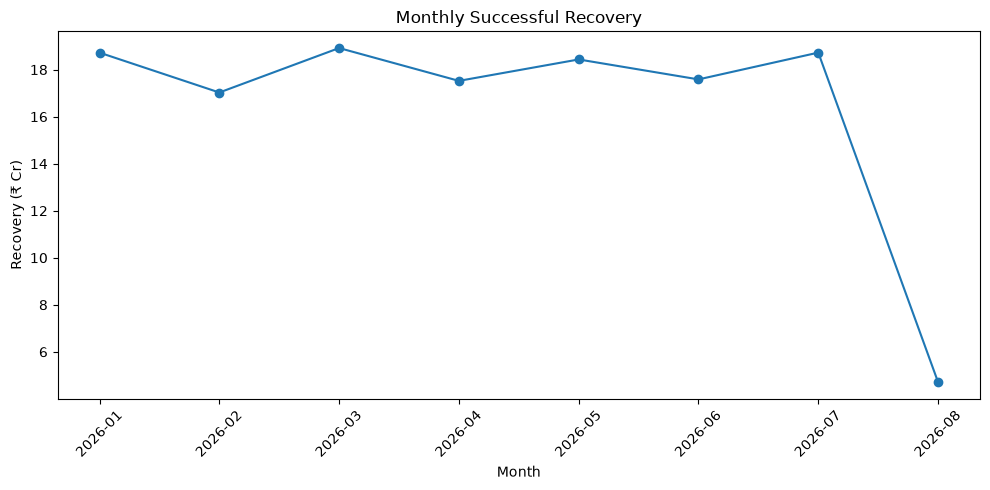

In [8]:
# Plot monthly recovery
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_recovery["month"],
    monthly_recovery["recovery_cr"],
    marker="o"
)

plt.title("Monthly Successful Recovery")
plt.xlabel("Month")
plt.ylabel("Recovery (₹ Cr)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [10]:
# Merge risk segment with successful payments
payment_risk = successful_payments.merge(
    accounts[["account_id", "risk_segment"]],
    on="account_id",
    how="left"
)

# Calculate recovery by risk segment
risk_recovery = (
    payment_risk
    .groupby("risk_segment")["amount"]
    .sum()
    .reset_index()
)

risk_recovery["recovery_cr"] = (
    risk_recovery["amount"] / 10_000_000
)

risk_recovery

,risk_segment,amount,recovery_cr
0,HIGH,3.317907e+08,33.179067
1,LOW,3.311408e+08,33.114078
2,MEDIUM,3.309252e+08,33.092520
3,NPA,3.226178e+08,32.261781


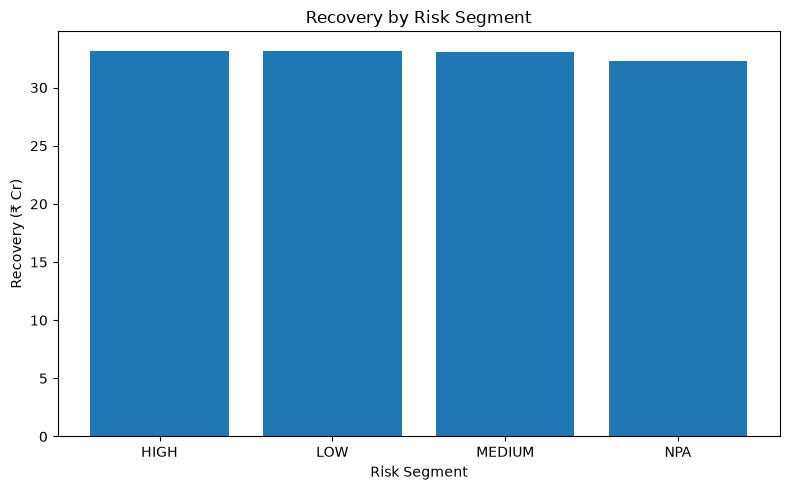

In [11]:
# Plot recovery by risk segment
plt.figure(figsize=(8, 5))

plt.bar(
    risk_recovery["risk_segment"],
    risk_recovery["recovery_cr"]
)

plt.title("Recovery by Risk Segment")
plt.xlabel("Risk Segment")
plt.ylabel("Recovery (₹ Cr)")

plt.tight_layout()
plt.show()

In [12]:
    # Combine collection channels
channel_data = pd.concat([
    calls[["account_id"]].assign(channel="Voice"),
    pd.read_csv("golden_dataset/whatsapp_events.csv")[["account_id"]].assign(channel="WhatsApp"),
    pd.read_csv("golden_dataset/sms_events.csv")[["account_id"]].assign(channel="SMS"),
    pd.read_csv("golden_dataset/field_visits.csv")[["account_id"]].assign(channel="Field")
])

# Count unique accounts by channel
channel_accounts = (
    channel_data
    .groupby("channel")["account_id"]
    .nunique()
    .reset_index(name="unique_accounts")
)

# Count unique recovered accounts
paid_accounts = (
    successful_payments
    .groupby("account_id")["amount"]
    .sum()
    .reset_index(name="recovered_amount")
)

channel_recovery = channel_data.merge(
    paid_accounts,
    on="account_id",
    how="inner"
)

channel_recovery = (
    channel_recovery
    .drop_duplicates(["channel", "account_id"])
    .groupby("channel")["account_id"]
    .nunique()
    .reset_index(name="recovered_accounts")
)

channel_summary = channel_accounts.merge(
    channel_recovery,
    on="channel",
    how="left"
)

channel_summary["recovery_rate_pct"] = (
    channel_summary["recovered_accounts"]
    / channel_summary["unique_accounts"]
    * 100
)

channel_summary

,channel,unique_accounts,recovered_accounts,recovery_rate_pct
0,Field,16908,7488,44.286728
1,SMS,23207,10310,44.426251
2,Voice,28408,12596,44.339623
3,WhatsApp,25924,11506,44.383583


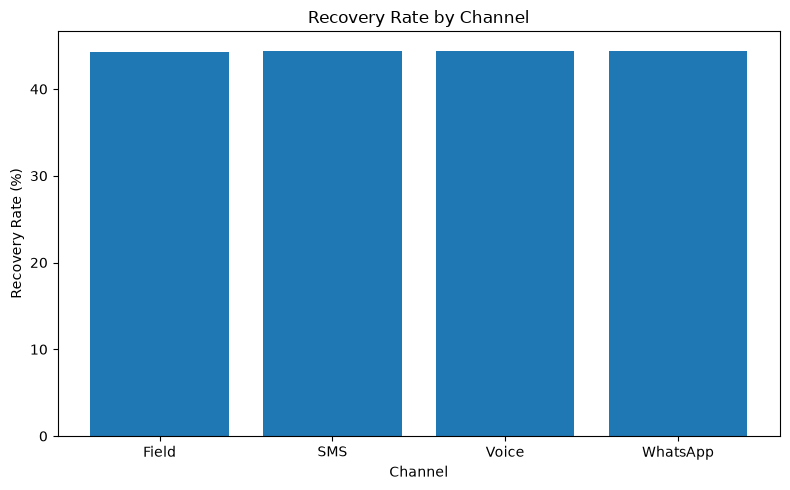

In [13]:
# Plot recovery rate by channel
plt.figure(figsize=(8, 5))

plt.bar(
    channel_summary["channel"],
    channel_summary["recovery_rate_pct"]
)

plt.title("Recovery Rate by Channel")
plt.xlabel("Channel")
plt.ylabel("Recovery Rate (%)")

plt.tight_layout()
plt.show()

In [14]:
# Calculate average monthly change
valid_mom = monthly_recovery["mom_change_pct"].dropna()

average_mom_change = valid_mom.mean()

# Count months meeting the 11% claim
months_above_11 = (
    monthly_recovery["mom_change_pct"] >= 11
).sum()

print(f"Average MoM recovery change: {average_mom_change:.2f}%")
print(f"Months meeting the 11% claim: {months_above_11}")

Average MoM recovery change: -10.44%
Months meeting the 11% claim: 1


In [15]:
# Prepare executive KPI values
july_recovery = monthly_recovery.loc[
    monthly_recovery["month"] == "2026-07", "recovery_cr"
].iloc[0]

march_mom = monthly_recovery.loc[
    monthly_recovery["month"] == "2026-03", "mom_change_pct"
].iloc[0]

print(f"July recovery: ₹{july_recovery:.2f} Cr")
print(f"March MoM improvement: {march_mom:.2f}%")
print("11% MoM claim: Not sustained")

July recovery: ₹18.72 Cr
March MoM improvement: 11.11%
11% MoM claim: Not sustained


In [16]:
# Counterfactual investment assessment
july_expected = 18.318394812
july_actual = 18.724783600

incremental_recovery = july_actual - july_expected
incremental_lakh = incremental_recovery * 100

print(f"July incremental recovery: ₹{incremental_lakh:.2f} lakh")
print("Investment recommendation: Pilot first")
print("Full ₹10 Cr rollout: Not recommended without controlled evidence")

July incremental recovery: ₹40.64 lakh
Investment recommendation: Pilot first
Full ₹10 Cr rollout: Not recommended without controlled evidence


## Executive Summary

### Key Findings

| KPI | Result |
|---|---:|
| July successful recovery | ₹18.72 Cr |
| March MoM improvement | 11.11% |
| 11% MoM claim | Not sustained |
| Channel recovery rate range | 44.29% – 44.43% |
| July incremental recovery vs counterfactual | ₹40.64 lakh |
| ₹10 Cr investment decision | Pilot first |

### Management Recommendation

The available evidence does not support an immediate full ₹10 Cr investment.

A controlled pilot with a holdout group should be conducted first. The pilot
should measure incremental recovery, cost per recovered rupee, and ROI.

The investment should be scaled only if the pilot demonstrates statistically
and economically meaningful incremental recovery.

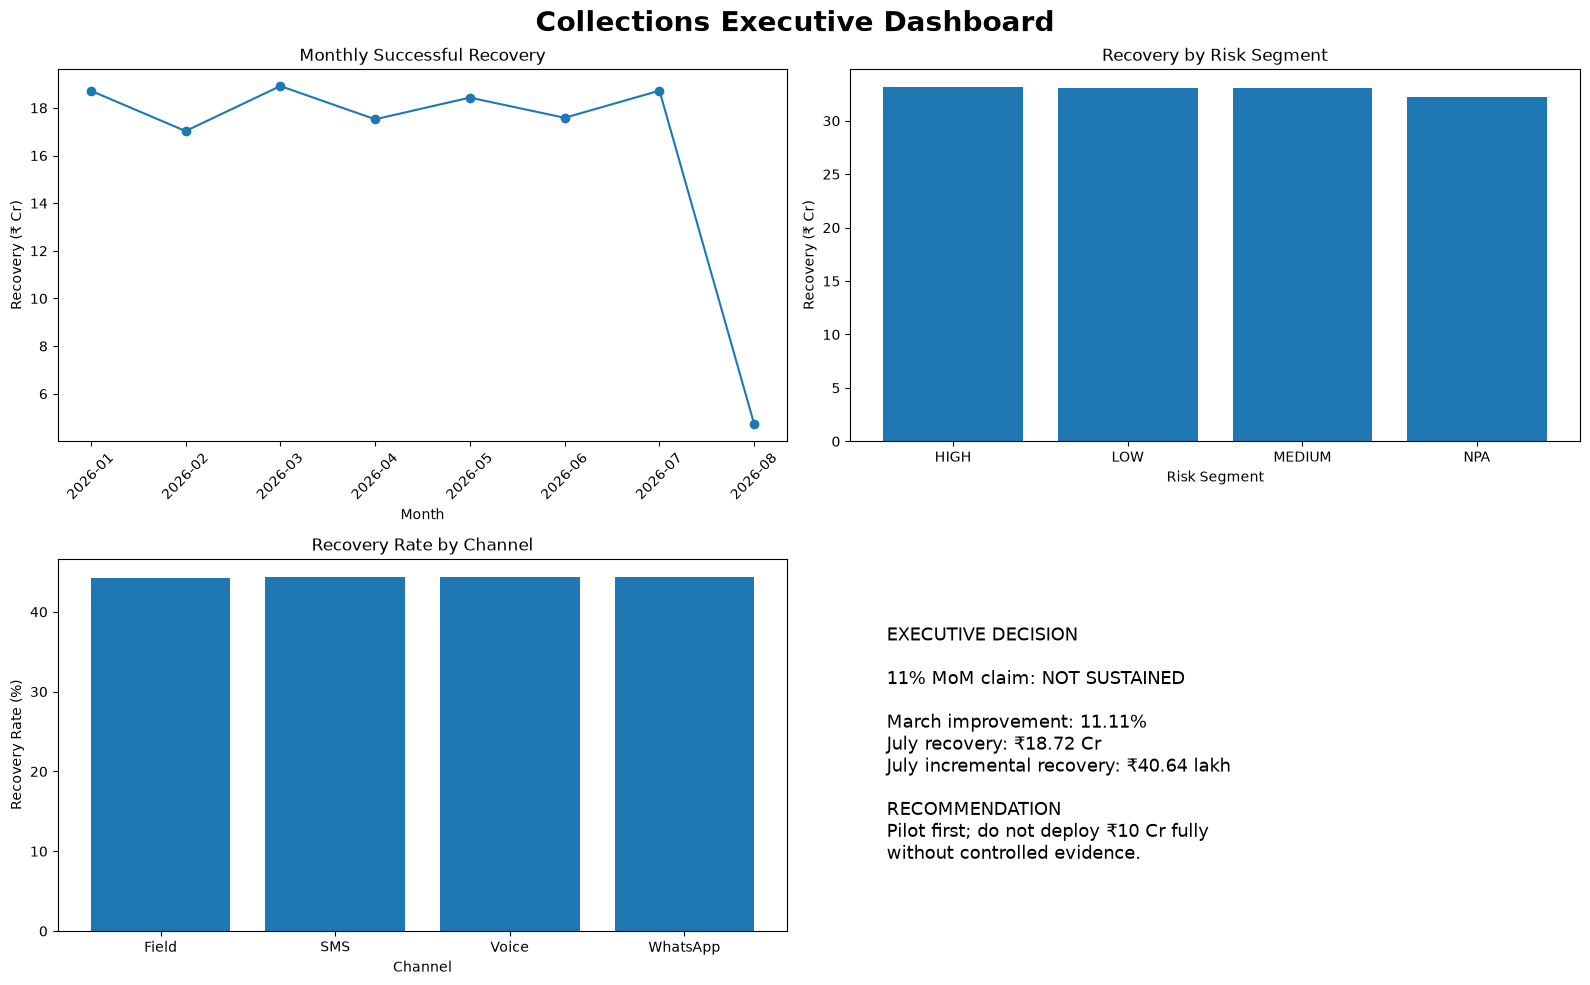

In [18]:
# Create executive dashboard
fig = plt.figure(figsize=(16, 10))

fig.suptitle(
    "Collections Executive Dashboard",
    fontsize=20,
    fontweight="bold"
)

# Recovery trend
ax1 = plt.subplot(2, 2, 1)

ax1.plot(
    monthly_recovery["month"],
    monthly_recovery["recovery_cr"],
    marker="o"
)

ax1.set_title("Monthly Successful Recovery")
ax1.set_xlabel("Month")
ax1.set_ylabel("Recovery (₹ Cr)")
ax1.tick_params(axis="x", rotation=45)

# Risk segment
ax2 = plt.subplot(2, 2, 2)

ax2.bar(
    risk_recovery["risk_segment"],
    risk_recovery["recovery_cr"]
)

ax2.set_title("Recovery by Risk Segment")
ax2.set_xlabel("Risk Segment")
ax2.set_ylabel("Recovery (₹ Cr)")

# Channel recovery
ax3 = plt.subplot(2, 2, 3)

ax3.bar(
    channel_summary["channel"],
    channel_summary["recovery_rate_pct"]
)

ax3.set_title("Recovery Rate by Channel")
ax3.set_xlabel("Channel")
ax3.set_ylabel("Recovery Rate (%)")

# Executive message
ax4 = plt.subplot(2, 2, 4)
ax4.axis("off")

summary_text = (
    "EXECUTIVE DECISION\n\n"
    "11% MoM claim: NOT SUSTAINED\n\n"
    "March improvement: 11.11%\n"
    "July recovery: ₹18.72 Cr\n"
    "July incremental recovery: ₹40.64 lakh\n\n"
    "RECOMMENDATION\n"
    "Pilot first; do not deploy ₹10 Cr fully\n"
    "without controlled evidence."
)

ax4.text(
    0.05,
    0.5,
    summary_text,
    fontsize=13,
    verticalalignment="center"
)

plt.tight_layout()
plt.show()